In [ ]:
# ======================================================
# Aula 19 – Normalizing Flows II
# Student Notebook (with TODOs)
# Implementing a MAF Flow for TwoSpirals
# ======================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cpu'

In [ ]:
# ======================================================
# TwoSpirals Dataset
# ======================================================

class TwoSpirals(Dataset):
    def __init__(self, num_points):
        self.num_points = num_points
        self._create_data()

    def __getitem__(self, item):
        return self.data[item]

    def __len__(self):
        return self.num_points

    def _create_data(self):
        n = torch.sqrt(torch.rand(self.num_points // 2)) * 540 * (2 * np.pi) / 360
        d1x = -torch.cos(n) * n + torch.rand(self.num_points // 2) * 0.5
        d1y = torch.sin(n) * n + torch.rand(self.num_points // 2) * 0.5
        x = torch.cat([
            torch.stack([d1x, d1y]).t(),
            torch.stack([-d1x, -d1y]).t()
        ])
        self.data = x / 3 + torch.randn_like(x) * 0.1


train_loader = DataLoader(TwoSpirals(128000), batch_size=128, shuffle=True)
test_loader  = DataLoader(TwoSpirals(128000), batch_size=128, shuffle=False)


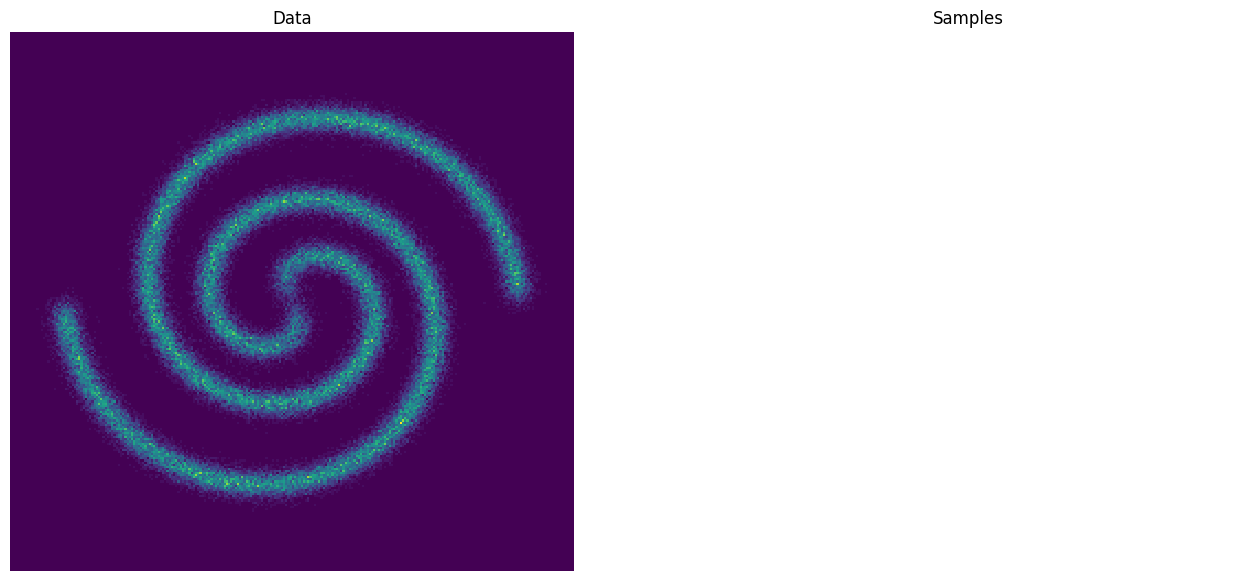

In [ ]:
# ======================================================
# Visualization Helper
# ======================================================

def plot_samples(samples=None, title_data="Data", title_samples="Samples"):
    d = test_loader.dataset.data.numpy()
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    ax[0].set_title(title_data)
    ax[1].set_title(title_samples)
    ax[0].axis("off")
    ax[1].axis("off")

    ax[0].hist2d(d[:,0], d[:,1], bins=256, range=[[-4,4],[-4,4]])

    if samples is not None:
        s = samples.detach().cpu().numpy()
        ax[1].hist2d(s[:,0], s[:,1], bins=256, range=[[-4,4],[-4,4]])

    plt.show()


plot_samples()


In [ ]:
# ======================================================
# Base Flow Model
# ======================================================

from torch.distributions import Normal

class Flow(nn.Module):
    def __init__(self, bijections):
        super().__init__()
        self.bijections = nn.ModuleList(bijections)

    @property
    def base_dist(self):
        return Normal(
            loc=torch.zeros(2, device=device),
            scale=torch.ones(2, device=device)
        )

    def log_prob(self, x):
        """Compute log p(x).  This is complete — students do not edit."""
        z = x
        logdet = torch.zeros(x.shape[0], device=device)

        for b in self.bijections:
            z, ld = b(z)
            logdet += ld

        return self.base_dist.log_prob(z).sum(1) + logdet

    def sample(self, N):
        """Sample x by inverting the flow.  Complete — students do not edit."""
        with torch.no_grad():
            z = self.base_dist.sample((N,))
            for b in reversed(self.bijections):
                z = b.inverse(z)
        return z


In [ ]:
# ======================================================
# Reverse Bijection (given)
# ======================================================

class Reverse(nn.Module):
    def forward(self, x):
        return x.flip(-1), torch.zeros(x.shape[0], device=device)

    def inverse(self, z):
        return z.flip(-1)

# ======================================================
# MADE-style Masked Linear Layer
# ======================================================

class MaskedLinear(nn.Linear):
    """
    Linear layer with a binary mask applied to weights.
    Students do NOT need to modify this.
    """
    def __init__(self, in_features, out_features, mask):
        super().__init__(in_features, out_features, bias=True)
        self.register_buffer("mask", mask)

    def forward(self, x):
        return nn.functional.linear(x, self.weight * self.mask, self.bias)


In [ ]:
# ======================================================
# Function to create MADE masks for 2D
# ======================================================

def create_masks(hidden_dim):
    """
    Masks for:
    x = [x1, x2]
    Output = [m1, s1, m2, s2]

    TODO: Students must complete.

    Return:
        masks = {
            "in_to_h": mask1,    # (hidden_dim, 2)
            "h_to_out": mask2    # (4, hidden_dim)
        }
    """

    # TODO:
    # 1. Define a simple autoregressive order for 2 variables.
    #    For example:
    #      degree(x1) = 1
    #      degree(x2) = 2
    #
    # 2. Sample hidden layer degrees in {1,2} (any valid autoregressive choice).
    #
    # 3. Create mask from input->hidden:
    #      mask[i,j] = 1 if degree(input_j) <= degree(hidden_i)
    #
    # 4. Create mask from hidden->output (4 outputs: m1, s1, m2, s2):
    #      - outputs for variable i can only depend on variables < i
    #      - i.e., (m1, s1) depend on nothing (degree 1)
    #      - (m2, s2) may depend on x1
    #
    # Return dictionary with both masks.

    # ========= YOUR CODE HERE =========
    raise NotImplementedError("Complete the masks for 2D MAF.")
    # ==================================


In [ ]:
# ======================================================
# MLP that outputs [m1, s1, m2, s2] for 2D MAF
# ======================================================

def make_made(hidden_dim=32):
    """
    Construct a MADE-style network using the masks produced above.
    Output size = 4 (m1, s1, m2, s2)
    """

    masks = create_masks(hidden_dim)

    net = nn.Sequential(
        MaskedLinear(2, hidden_dim, masks["in_to_h"]),
        nn.ReLU(),
        MaskedLinear(hidden_dim, 4, masks["h_to_out"])
    )
    return net


In [ ]:
# ======================================================
# MAF Bijection (students implement forward and inverse)
# ======================================================

class MAF(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.net = net   # MADE-style autoregressive network

    def forward(self, x):
        """
        Compute z = f(x) and log|det J|.

        TODO:
        1. Compute h = self.net(x)  → shape (B, 4)
        2. Split into m1, s1, m2, s2
        3. Use autoregressive factorization:
           z1 = (x1 - m1) * exp(-s1)
           z2 = (x2 - m2(x1)) * exp(-s2(x1))
        4. Compute logdet = -(s1 + s2)
        5. Return (z, logdet)
        """

        # ========= YOUR CODE HERE =========
        raise NotImplementedError("Implement the forward pass of MAF.")
        # ==================================

    def inverse(self, z):
        """
        Compute x = f^{-1}(z).  This is autoregressive in x.

        TODO:
        1. x1 = m1 + z1 * exp(s1)
           where (m1, s1) = self.net([x1, something]) BUT
           NOTE: m1, s1 depend only on x1 (not x2)
        2. Then compute x2 using z2 and (m2, s2(x1))

        Hint:
        - You will need to compute x1 FIRST.
        - Construct an input like (x1, 0) or (x1, dummy) to feed net.
        """

        # ========= YOUR CODE HERE =========
        raise NotImplementedError("Implement the inverse pass of MAF.")
        # ==================================


In [ ]:
# ======================================================
# Build the flow model
# ======================================================

def build_flow():
    return Flow([
        MAF(make_made()).to(device),
        Reverse().to(device),
        MAF(make_made()).to(device),
    ]).to(device)


flow = build_flow()
flow


NotImplementedError: Complete the masks for 2D MAF.

In [ ]:
# ======================================================
# Plot samples at initialization
# ======================================================
with torch.no_grad():
    s0 = flow.sample(128000)

plot_samples(s0, title_samples="Flow samples (initialization)")


NameError: name 'flow' is not defined

In [ ]:
# ======================================================
# Training Loop
# ======================================================

optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
epochs = 10

print("Training...")

flow.train()
for epoch in range(epochs):
    total_loss = 0.0

    for x in train_loader:
        x = x.to(device)
        optimizer.zero_grad()

        # TODO: write the negative log-likelihood
        # loss = ???
        # ========= YOUR CODE HERE =========
        raise NotImplementedError("Define loss = -flow.log_prob(x).mean()")
        # ==================================

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss = {total_loss/len(train_loader):.3f}")

flow.eval()


NameError: name 'flow' is not defined

In [ ]:
# ======================================================
# Plot samples after training
# ======================================================
with torch.no_grad():
    samples = flow.sample(128000)

plot_samples(samples, title_samples="Flow samples (trained)")


NameError: name 'flow' is not defined